# Wildlife Strike Damage Prediction
**Model:** HistGradientBoostingClassifier with optimized threshold
**Best validation balanced accuracy:** 83.56%

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
import time, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [125]:
train_df = pd.read_csv('train.csv/train.csv')
test_df  = pd.read_csv('test.csv/test.csv')
print('Training set shape:', train_df.shape)
print('Test set shape:',      test_df.shape)
print(f'Damage rate: {train_df["INDICATED_DAMAGE"].mean():.4f}')

Training set shape: (307178, 55)
Test set shape: (34131, 54)
Damage rate: 0.0636


In [126]:
# Feature engineering and leak-free preprocessing
DROP_COLS = ['INDEX_NR','INCIDENT_DATE','REMARKS','COMMENTS','LUPDATE',
             'TRANSFER','BIRD_BAND_NUMBER','REG','FLT','SIZE']
SIZE_MAP  = {'Small':1,'Medium':2,'Large':3}

def parse_hour(series):
    def _p(v):
        if pd.isna(v) or str(v).strip().lower() in ('','unknown'): return np.nan
        try: return float(str(v).split(':')[0])
        except: return np.nan
    return series.apply(_p)

def hour_bucket(h):
    if pd.isna(h): return np.nan
    if h<6:  return 1.0
    if h<12: return 2.0
    if h<18: return 3.0
    return 4.0

class Preprocessor:
    """Fits encoders on training data only, applies same transform to test."""
    def __init__(self): self.cat_maps={}; self.cols=None

    def fit_transform(self, df, target='INDICATED_DAMAGE'):
        df=df.copy()
        df=df.drop(columns=[c for c in DROP_COLS if c in df.columns],errors='ignore')
        if 'SIZE' in df.columns: df['SIZE_ORDINAL']=df['SIZE'].map(SIZE_MAP)
        df['TIME_HOUR']=parse_hour(df['TIME'])
        df['TIME_BUCKET']=df['TIME_HOUR'].apply(hour_bucket)
        df=df.drop(columns=['TIME'],errors='ignore')
        y=None
        if target in df.columns: y=df[target].copy(); df=df.drop(columns=[target])
        for col in df.select_dtypes(include=['object']).columns:
            u=sorted(df[col].dropna().astype(str).unique().tolist())
            mp={v:i for i,v in enumerate(u)}; self.cat_maps[col]=mp
            df[col]=df[col].astype(str).map(mp).astype(float)
        self.cols=df.columns.tolist(); return df,y

    def transform(self, df):
        df=df.copy()
        df=df.drop(columns=[c for c in DROP_COLS if c in df.columns],errors='ignore')
        if 'INDICATED_DAMAGE' in df.columns: df=df.drop(columns=['INDICATED_DAMAGE'])
        if 'SIZE' in df.columns: df['SIZE_ORDINAL']=df['SIZE'].map(SIZE_MAP)
        df['TIME_HOUR']=parse_hour(df['TIME'])
        df['TIME_BUCKET']=df['TIME_HOUR'].apply(hour_bucket)
        df=df.drop(columns=['TIME'],errors='ignore')
        for col,mp in self.cat_maps.items():
            if col in df.columns: df[col]=df[col].astype(str).map(mp).astype(float)
        return df[self.cols]

prep=Preprocessor()
X_train,y_train=prep.fit_transform(train_df)
X_test=prep.transform(test_df)
print(f'Training features: {X_train.shape[1]}')

Training features: 45


In [127]:
# Train/validation split (stratified to preserve class ratio)
X_tr,X_val,y_tr,y_val=train_test_split(
    X_train,y_train,test_size=0.2,random_state=42,stratify=y_train
)
neg,pos=(y_tr==0).sum(),(y_tr==1).sum()
sw=np.where(y_tr==1,neg/pos,1.0)
print(f'Train:{len(X_tr)}  Val:{len(X_val)}  pos_weight:{neg/pos:.1f}x')

Train:245742  Val:61436  pos_weight:14.7x


In [128]:
# Train HistGradientBoostingClassifier
# - Handles missing values natively (no imputation bias)
# - Sequential boosting corrects previous errors
# - early_stopping finds optimal iteration count automatically
model=HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=1
)
t0=time.time()
print('Training...')
model.fit(X_tr,y_tr,sample_weight=sw)
print(f'Done in {time.time()-t0:.1f}s  |  Iterations: {model.n_iter_}')
y_val_proba=model.predict_proba(X_val)[:,1]

Training...
Binning 0.080 GB of training data: 0.263 s
Binning 0.009 GB of validation data: 0.011 s
Fitting gradient boosted rounds:
Fit 258 trees in 8.068 s, (7998 total leaves)
Time spent computing histograms: 3.960s
Time spent finding best splits:  0.639s
Time spent applying splits:      0.859s
Time spent predicting:           0.169s
Done in 8.1s  |  Iterations: 258


VALIDATION RESULTS
Threshold:         0.460
Balanced Accuracy: 0.8313 (83.13%)
ROC-AUC:           0.9155
Standard Accuracy: 0.8164
Precision:         0.2366
Recall:            0.8484
F1-Score:          0.3700
              precision    recall  f1-score   support

   No Damage       0.99      0.81      0.89     57531
      Damage       0.24      0.85      0.37      3905

    accuracy                           0.82     61436
   macro avg       0.61      0.83      0.63     61436
weighted avg       0.94      0.82      0.86     61436



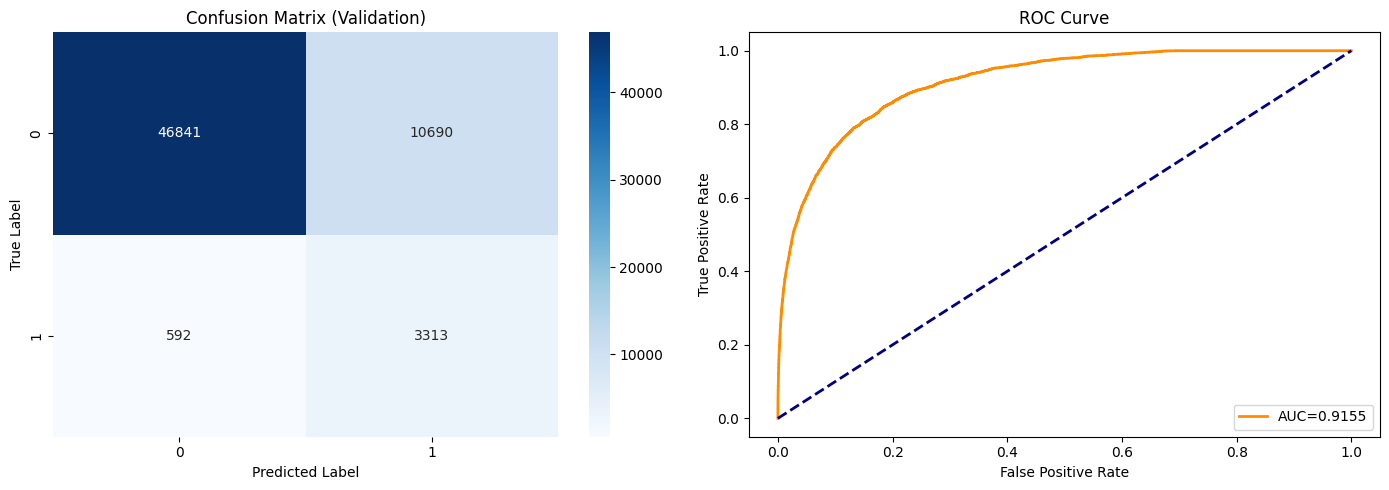

In [129]:
# Threshold tuning: find threshold that maximises balanced accuracy
# Default 0.5 is suboptimal for imbalanced datasets
ths=np.linspace(0.05,0.95,181)
bas=[balanced_accuracy_score(y_val,(y_val_proba>=t).astype(int)) for t in ths]
best_t=ths[int(np.argmax(bas))]; best_ba=max(bas)
y_vp=(y_val_proba>=best_t).astype(int)
auc=roc_auc_score(y_val,y_val_proba)

print('='*60)
print('VALIDATION RESULTS')
print('='*60)
print(f'Threshold:         {best_t:.3f}')
print(f'Balanced Accuracy: {best_ba:.4f} ({best_ba*100:.2f}%)')
print(f'ROC-AUC:           {auc:.4f}')
print(f'Standard Accuracy: {accuracy_score(y_val,y_vp):.4f}')
print(f'Precision:         {precision_score(y_val,y_vp,zero_division=0):.4f}')
print(f'Recall:            {recall_score(y_val,y_vp,zero_division=0):.4f}')
print(f'F1-Score:          {f1_score(y_val,y_vp,zero_division=0):.4f}')
print('='*60)
print(classification_report(y_val,y_vp,target_names=['No Damage','Damage']))

cm=confusion_matrix(y_val,y_vp)
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Confusion Matrix (Validation)')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
fpr,tpr,_=roc_curve(y_val,y_val_proba)
axes[1].plot(fpr,tpr,color='darkorange',lw=2,label=f'AUC={auc:.4f}')
axes[1].plot([0,1],[0,1],'navy',lw=2,linestyle='--')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

In [130]:
# Retrain on full training data using iteration count from early stopping
nf,pf=(y_train==0).sum(),(y_train==1).sum()
swf=np.where(y_train==1,nf/pf,1.0)

final_model=HistGradientBoostingClassifier(
    max_iter=model.n_iter_,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    early_stopping=False,
    random_state=42,
    verbose=1
)
t0=time.time()
print(f'Retraining on full dataset ({model.n_iter_} iterations)...')
final_model.fit(X_train,y_train,sample_weight=swf)
print(f'Done in {time.time()-t0:.1f}s')

y_test_proba=final_model.predict_proba(X_test)[:,1]
y_test_pred=(y_test_proba>=best_t).astype(int)

submission=pd.DataFrame({'INDEX_NR':test_df['INDEX_NR'],'INDICATED_DAMAGE':y_test_pred})
submission.to_csv('submission.csv',index=False)
print('Saved submission.csv')
print(submission.head(10))
print(f'Total:{len(submission)}  Damage:{(submission["INDICATED_DAMAGE"]==1).sum()}  No damage:{(submission["INDICATED_DAMAGE"]==0).sum()}')

Retraining on full dataset (258 iterations)...
Binning 0.111 GB of training data: 0.284 s
Fitting gradient boosted rounds:
Fit 258 trees in 8.593 s, (7998 total leaves)
Time spent computing histograms: 5.243s
Time spent finding best splits:  0.607s
Time spent applying splits:      0.999s
Time spent predicting:           0.208s
Done in 8.6s
Saved submission.csv
   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 0
5   9000005                 1
6   9000006                 0
7   9000007                 0
8   9000008                 0
9   9000009                 0
Total:34131  Damage:8019  No damage:26112
